## 1. Imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

## 2. Carregamento dos Dados

In [3]:
ratings = pd.read_csv('../Mini_trabalho_6/dados_processados/ratings_processado.csv')
print(ratings.shape)

(90274, 6)


## 3. Validação Cruzada - SVD base (n=50)

In [13]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

rmses = []

for fold, (train_idx, test_idx) in enumerate(kf.split(ratings)):
    train = ratings.iloc[train_idx]
    test  = ratings.iloc[test_idx]
    
    media_global = train['rating'].mean()
    
    matriz = train.pivot_table(index='userId', columns='movieId', values='rating').fillna(media_global)
    
    svd = TruncatedSVD(n_components=50, random_state=42)
    matriz_reduzida = svd.fit_transform(matriz)
    df_reconstruida = pd.DataFrame(svd.inverse_transform(matriz_reduzida),
                                   index=matriz.index, columns=matriz.columns)
    
    preds = []
    for _, row in test.iterrows():
        user, movie = row['userId'], row['movieId']
        if user in df_reconstruida.index and movie in df_reconstruida.columns:
            preds.append(df_reconstruida.loc[user, movie])
        else:
            preds.append(media_global)
    
    rmse = np.sqrt(mean_squared_error(test['rating'], preds))
    rmses.append(rmse)
    print(f'Fold {fold+1}: RMSE = {rmse:.4f}')

print(f'\nRMSE médio: {np.mean(rmses):.4f} ± {np.std(rmses):.4f}')

Fold 1: RMSE = 0.9886
Fold 2: RMSE = 0.9935
Fold 3: RMSE = 0.9815
Fold 4: RMSE = 0.9968
Fold 5: RMSE = 0.9846

RMSE médio: 0.9890 ± 0.0056


## 4. Otimização de Hiperparâmetros - n_components


In [10]:
componentes = [10, 20, 50, 100, 150]
resultados = []

for n in componentes:
    rmses_fold = []
    
    for train_idx, test_idx in kf.split(ratings):
        train = ratings.iloc[train_idx]
        test  = ratings.iloc[test_idx]
        
        media_global = train['rating'].mean()
        matriz = train.pivot_table(index='userId', columns='movieId', values='rating').fillna(media_global)
        
        svd = TruncatedSVD(n_components=n, random_state=42)
        matriz_reduzida = svd.fit_transform(matriz)
        df_reconstruida = pd.DataFrame(svd.inverse_transform(matriz_reduzida),
                                       index=matriz.index, columns=matriz.columns)
        
        preds = []
        for _, row in test.iterrows():
            user, movie = row['userId'], row['movieId']
            if user in df_reconstruida.index and movie in df_reconstruida.columns:
                preds.append(df_reconstruida.loc[user, movie])
            else:
                preds.append(media_global)
        
        rmses_fold.append(np.sqrt(mean_squared_error(test['rating'], preds)))
    
    media = np.mean(rmses_fold)
    resultados.append({'n_components': n, 'rmse_medio': media, 'std': np.std(rmses_fold)})
    print(f'n_components={n}: RMSE = {media:.4f} ± {np.std(rmses_fold):.4f}')

df_resultados = pd.DataFrame(resultados)

n_components=10: RMSE = 0.9728 ± 0.0043
n_components=20: RMSE = 0.9750 ± 0.0046
n_components=50: RMSE = 0.9890 ± 0.0056
n_components=100: RMSE = 1.0040 ± 0.0048
n_components=150: RMSE = 1.0143 ± 0.0048


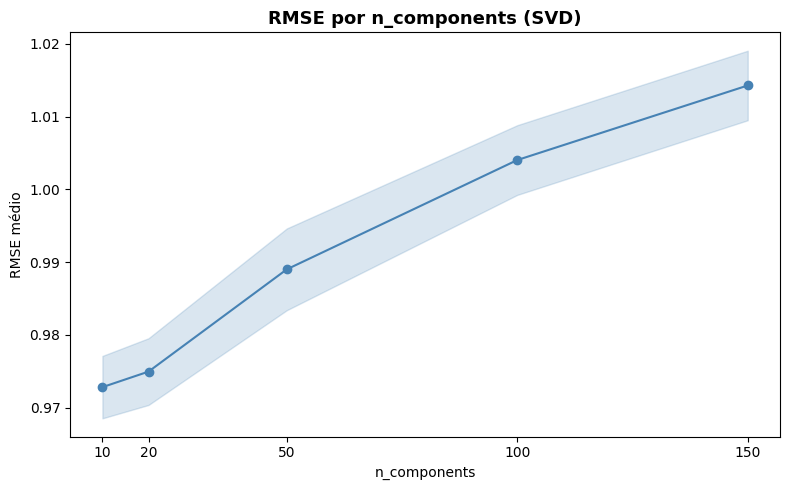

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(df_resultados['n_components'], df_resultados['rmse_medio'], marker='o', color='steelblue')
plt.fill_between(df_resultados['n_components'],
                 df_resultados['rmse_medio'] - df_resultados['std'],
                 df_resultados['rmse_medio'] + df_resultados['std'],
                 alpha=0.2, color='steelblue')
plt.title('RMSE por n_components (SVD)', fontsize=13, fontweight='bold')
plt.xlabel('n_components')
plt.ylabel('RMSE médio')
plt.xticks(df_resultados['n_components'])
plt.tight_layout()
plt.savefig('assets/otimizacao_ncomponents.png')
plt.show()

## 5. Comparação Antes vs Depois

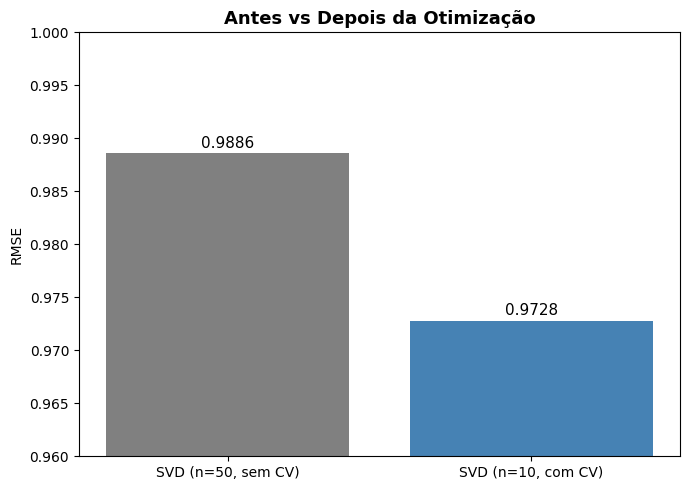

In [12]:
comparacao = {
    'Modelo': ['SVD (n=50, sem CV)', 'SVD (n=10, com CV)'],
    'RMSE': [0.9886, 0.9728]
}

df_comp = pd.DataFrame(comparacao)

plt.figure(figsize=(7, 5))
bars = plt.bar(df_comp['Modelo'], df_comp['RMSE'], color=['gray', 'steelblue'])
plt.ylim(0.96, 1.00)
plt.title('Antes vs Depois da Otimização', fontsize=13, fontweight='bold')
plt.ylabel('RMSE')

for bar, rmse in zip(bars, df_comp['RMSE']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
             f'{rmse:.4f}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('assets/antes_depois.png')
plt.show()

## 6. Conclusões

A validação cruzada foi aplicada dividindo os dados em 5 partes (folds) ao invés do split padrão treino/teste. A cada iteração, o modelo foi treinado em 4 folds e testado no restante, resultando em um RMSE médio de **0.9890 ± 0.0056**. O baixo desvio padrão indica que o modelo é consistente e não apresenta sobreajuste.

Na otimização de hiperparâmetros, testamos diferentes valores de `n_components` (10, 20, 50, 100 e 150). O resultado mostrou que **quanto menor o número de componentes, melhor a performance** — o modelo com `n_components=10` obteve o melhor RMSE de **0.9728**. Isso ocorre porque menos componentes capturam apenas os padrões mais relevantes dos dados, evitando que o modelo memorize ruído (overfitting).

A otimização representou uma melhora de **0.0158** que representa **1,6%** de melhora no RMSE em relação ao modelo inicial com `n_components=50`.